# Modelo elegido

En el anterior notebook estuvimos realizando multiples pruebas con modelos probando modelos altermativos individuales, sin embargo los resultados no fueron tan prometedores, a pesar de que se usaron varios metodos para mejorar las iamgenes. Para llegar a esta conclusión de elección de modelo, se hicieron multiples pruebas en un archivo que esta agregado en la carpeta de modelos/ con el nombre de modelos_alternativos_finales.ipynb. 

El presente notebook tiene como objetivo de todas las multiples pruebas que se hicieron verificar de manera aislada lo que fue nuestro mejor modelo en las pruebas anteriores, mismo que sirvio para mejorar los resultados obtenidos en el anterior archivo. 

Nuestro modelo usa Zoobot que fue preentrenado sobre cutouts a color de Legacy Survey. Esto con el fin de ver que tanto se modificaba con los modelos que incluian nuestro preprocesado custom con unsharp mask + normalización por-banda y era una entrada fuera de distribución. Al darle imágenes naturales con colorización Lupton grz, sin unsharp, color preservado el F1 saltó de 0.671 a **0.731 (+0.06)**.

Pipeline:
- Carga grz crudo de los FITS
- **Colorización Lupton** (`astropy.visualization.make_lupton_rgb`, z→R r→G g→B, stretch=0.2 Q=8) → RGB natural [0,255].
- Cache en uint8 (`natural_cache_grz_320.npz`); el dataset hace /255 + normalización ImageNet
- Zoobot-Base finetune `stages.2+3+head`, 320px, label smoothing, AMP train, **inferencia fp32**, TTA, early stopping en val-F1.


In [ ]:
# Config + imports
import time, json, re, glob, os, copy
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn, timm
from astropy.io import fits
from astropy.visualization import make_lupton_rgb
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             accuracy_score, confusion_matrix)

ROOT, OUT_DIR = Path.cwd(), Path.cwd() / "outputs"
DATA_DIR = ROOT / "data_download" / "data"
CSV_PATH = ROOT / "data_download" / "classification_dataset.csv"
ENCODER  = "hf_hub:mwalmsley/zoobot-encoder-convnext_base"

IMG_SIZE, BATCH_SIZE = 320, 16
STRETCH, Q   = 0.2, 8            # colorización Lupton
DEEP_FINETUNE = True            # descongelar stages.2 + stages.3 + head
LR, WEIGHT_DECAY = 1e-4, 1e-4
WEIGHT_ALPHA, LABEL_SMOOTHING = 1.0, 0.05
MAX_EPOCHS, PATIENCE = 15, 4
USE_TTA, RANDOM_SEED, NUM_WORKERS = True, 42, 0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
NAT_CACHE = OUT_DIR / f"natural_cache_grz_{IMG_SIZE}.npz"
print(f"Device: {DEVICE} | encoder: {ENCODER.split('/')[-1]} | cache natural existe: {NAT_CACHE.exists()}")

/home/camilo/Documents/school/proyecto-integrador/baseline/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda | encoder: zoobot-encoder-convnext_base | cache natural existe: True


In [ ]:
# === Cache de imagenes  /  manejo un rgb 
def _centroid(img, sf=0.4):
    hh, ww = img.shape; dy, dx = int(hh*sf/2), int(ww*sf/2)
    y0, y1, x0, x1 = hh//2-dy, hh//2+dy, ww//2-dx, ww//2+dx
    s = img[y0:y1, x0:x1]; ly, lx = np.unravel_index(np.argmax(s), s.shape)
    return y0+int(ly), x0+int(lx)

def _crop(im, yc, xc, sz=IMG_SIZE):
    hh, ww = im.shape; h2 = sz//2
    y0, y1, x0, x1 = yc-h2, yc+h2, xc-h2, xc+h2
    py0, py1 = max(0, -y0), max(0, y1-hh); px0, px1 = max(0, -x0), max(0, x1-ww)
    im = np.pad(im, ((py0, py1), (px0, px1))); y0+=py0; y1+=py0; x0+=px0; x1+=px0
    return im[y0:y1, x0:x1]

def build_natural_cache():
    df = pd.read_csv(CSV_PATH); lab = dict(zip(df.name.astype(str), df.label))
    pat = re.compile(r'_([^_]+)_ra'); n2p = {}
    for f in glob.glob(str(DATA_DIR / "*.fits")):
        m = pat.search(Path(f).name)
        if m: n2p[m.group(1)] = f
    imgs, labels, names = [], [], []
    keys = [n for n in df.name.astype(str) if n in n2p]
    print(f"Construyendo cache natural Lupton ({len(keys)} galaxias, ~3-4 min)...")
    for i, n in enumerate(keys):
        if i and i % 1500 == 0: print(f"  {i}/{len(keys)} OK={len(imgs)}")
        try:
            with fits.open(n2p[n], memmap=False) as h: dd = h[0].data
            if dd is None or dd.ndim != 3 or dd.shape[0] < 3: continue
            g, r, z = [np.nan_to_num(np.asarray(dd[k], dtype=np.float64)) for k in range(3)]
            if not np.any(np.isfinite(r)): continue
            yc, xc = _centroid(r); g, r, z = [_crop(x, yc, xc) for x in (g, r, z)]
            if r.shape != (IMG_SIZE, IMG_SIZE): continue
            rgb = make_lupton_rgb(z, r, g, minimum=0, stretch=STRETCH, Q=Q)  # z=R r=G g=B
            imgs.append(rgb.astype(np.uint8)); labels.append(int(lab[n])); names.append(n)
        except Exception:
            continue
    imgs = np.stack(imgs); labels = np.array(labels, np.int64); names = np.array(names)
    np.savez_compressed(NAT_CACHE, imgs=imgs, labels=labels, names=names)
    print(f"Guardado {NAT_CACHE.name} {imgs.shape}")
    return imgs, labels, names

if NAT_CACHE.exists():
    _d = np.load(NAT_CACHE, allow_pickle=True)
    X_imgs, X_labels, X_names = _d["imgs"], _d["labels"], _d["names"]
    print(f"Cache natural cargado: {X_imgs.shape} (uint8 RGB)")
else:
    X_imgs, X_labels, X_names = build_natural_cache()

# Split estratificado 70/15/15
np.random.seed(RANDOM_SEED)
def _split(labels):
    parts = {}
    for c in (0, 1):
        ix = np.where(labels == c)[0]; np.random.shuffle(ix); n = len(ix)
        parts[c] = (ix[:int(n*.7)], ix[int(n*.7):int(n*.85)], ix[int(n*.85):])
    tr = np.concatenate([parts[0][0], parts[1][0]]); np.random.shuffle(tr)
    return tr, np.concatenate([parts[0][1], parts[1][1]]), np.concatenate([parts[0][2], parts[1][2]])
idx_train, idx_val, idx_test = _split(X_labels)
y_train, y_val, y_test = X_labels[idx_train], X_labels[idx_val], X_labels[idx_test]
print(f"Split: train={len(idx_train)} val={len(idx_val)} test={len(idx_test)} test_cls={np.bincount(y_test).tolist()}")

Cache natural cargado: (8379, 320, 320, 3) (uint8 RGB)
Split: train=5865 val=1257 test=1257 test_cls=[996, 261]


In [ ]:
# Dataset e imagenes sin tocar el color
class GalaxyDS(Dataset):
    IMEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    ISTD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    def __init__(self, ix, y, augment=False):
        self.ix, self.y = ix, y
        self.tf = (T.Compose([T.RandomHorizontalFlip(0.5), T.RandomVerticalFlip(0.5),
                              T.RandomRotation(180, interpolation=T.InterpolationMode.BILINEAR)])
                   if augment else nn.Identity())
    def __len__(self): return len(self.ix)
    def __getitem__(self, i):
        rgb = X_imgs[self.ix[i]].astype(np.float32) / 255.0     # (H,W,3) color preservado
        t = torch.from_numpy(rgb).permute(2, 0, 1)              # (3,H,W)
        t = self.tf(t)
        return (t - self.IMEAN) / self.ISTD, int(self.y[i])

_pin = (DEVICE == "cuda")
dl_train = DataLoader(GalaxyDS(idx_train, y_train, True),  BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=_pin)
dl_val   = DataLoader(GalaxyDS(idx_val,   y_val),          BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=_pin)
dl_test  = DataLoader(GalaxyDS(idx_test,  y_test),         BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=_pin)
print("DataLoaders listos (representación natural).")

DataLoaders listos (representación natural).


In [ ]:
# Zoobot-Base
def build_zoobot_base(num_classes=2, deep=True):
    m = timm.create_model(ENCODER, pretrained=True, num_classes=num_classes)
    for p in m.parameters(): p.requires_grad = False
    keys = ("stages.2","stages.3","norm_pre","head") if deep else ("stages.3","norm_pre","head")
    for n, p in m.named_parameters():
        if n.startswith(keys): p.requires_grad = True
    return m

model = build_zoobot_base(deep=DEEP_FINETUNE).to(DEVICE)
n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_t  = sum(p.numel() for p in model.parameters())
print(f"Zoobot-Base: {n_tr:,}/{n_t:,} entrenables ({100*n_tr/n_t:.1f}%)")

counts = np.bincount(y_train, minlength=2).astype(np.float64)
w = (1.0/counts)**WEIGHT_ALPHA; w /= w.mean()
class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else None

def train_one_epoch():
    model.train(True); tot, n = 0.0, 0
    for x, y in dl_train:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
            loss = criterion(model(x), y)
        optimizer.zero_grad(set_to_none=True)
        if scaler is not None: scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else: loss.backward(); optimizer.step()
        tot += loss.item()*x.size(0); n += x.size(0)
    return tot/n

@torch.no_grad()
def predict_probs(loader, tta=False):
    model.eval(); ps, ys = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        views = ([x, torch.flip(x,[-1]), torch.flip(x,[-2]), torch.rot90(x,1,[-2,-1]),
                  torch.rot90(x,2,[-2,-1]), torch.rot90(x,3,[-2,-1])] if tta else [x])
        acc = 0.0
        for v in views: acc = acc + torch.softmax(model(v).float(), 1)[:, 1]   # fp32
        ps.extend((acc/len(views)).cpu().numpy().tolist()); ys.extend(y.tolist())
    return np.nan_to_num(np.asarray(ps), nan=0.5), np.asarray(ys)

Zoobot-Base: 85,397,506/87,568,514 entrenables (97.5%)


In [ ]:
# Entrenamiento early stopping val-F1
best_f1, best_state, no_improve, t0 = -1.0, None, 0, time.time()
print(f"Entrenando hasta {MAX_EPOCHS} épocas (paciencia={PATIENCE})...")
for epoch in range(1, MAX_EPOCHS + 1):
    tl = train_one_epoch()
    vp, vy = predict_probs(dl_val, tta=False)
    vf1 = f1_score(vy, (vp >= 0.5).astype(int), zero_division=0)
    flag = ""
    if vf1 > best_f1 + 1e-4:
        best_f1, best_state, no_improve = vf1, copy.deepcopy(model.state_dict()), 0; flag = " *"
    else: no_improve += 1
    print(f"Epoch {epoch:2d}/{MAX_EPOCHS}  tr_loss={tl:.4f}  val_F1={vf1:.4f}{flag}  [{(time.time()-t0)/60:.1f} min]")
    if no_improve >= PATIENCE: print(f"Early stopping en epoch {epoch}"); break
if best_state is not None: model.load_state_dict(best_state)
print(f"\nMejor val_F1: {best_f1:.4f} | {(time.time()-t0)/60:.1f} min")
if DEVICE == "cuda": torch.cuda.empty_cache()

Entrenando hasta 15 épocas (paciencia=4)...
Epoch  1/15  tr_loss=0.5467  val_F1=0.6745 *  [1.5 min]
Epoch  2/15  tr_loss=0.4707  val_F1=0.7067 *  [2.9 min]
Epoch  3/15  tr_loss=0.4440  val_F1=0.7108 *  [4.3 min]
Epoch  4/15  tr_loss=0.4178  val_F1=0.7240 *  [5.7 min]
Epoch  5/15  tr_loss=0.3947  val_F1=0.7264 *  [7.1 min]
Epoch  6/15  tr_loss=0.3667  val_F1=0.7208  [8.5 min]
Epoch  7/15  tr_loss=0.3580  val_F1=0.7214  [9.9 min]
Epoch  8/15  tr_loss=0.3394  val_F1=0.6988  [11.3 min]
Epoch  9/15  tr_loss=0.3207  val_F1=0.7187  [12.7 min]
Early stopping en epoch 9

Mejor val_F1: 0.7264 | 12.7 min


In [ ]:
# Evaluación final test, fp32 + TTA
def tune_threshold(yv, pv):
    ths = np.linspace(0.05, 0.95, 181)
    return float(ths[int(np.argmax([f1_score(yv, (pv >= t).astype(int), zero_division=0) for t in ths]))])

val_p, _      = predict_probs(dl_val,  tta=USE_TTA)
test_p, test_y = predict_probs(dl_test, tta=USE_TTA)
THR = tune_threshold(y_val, val_p)
pred = (test_p >= THR).astype(int)
P = precision_score(test_y, pred, zero_division=0); R = recall_score(test_y, pred, zero_division=0)
F = f1_score(test_y, pred, zero_division=0); A = accuracy_score(test_y, pred)
tn, fp, fn, tp = confusion_matrix(test_y, pred, labels=[0, 1]).ravel()

print("=" * 58)
print(f"ZOOBOT-BASE + NATURAL @ {IMG_SIZE}px  (test n={len(test_y)}, thr={THR:.2f}, TTA={USE_TTA})")
print(f"  Acc={A:.4f}  P={P:.4f}  R={R:.4f}  F1={F:.4f}   TN={tn} FP={fp} FN={fn} TP={tp}")
print("-" * 58)
print(f"  Comparación:  Base+unsharp=0.671 | Nano+unsharp=0.668 | baseline original=0.515")
print(f"  -> ganancia por REPRESENTACIÓN natural: +{F-0.671:.3f}")
print("=" * 58)

pd.DataFrame({"name": X_names[idx_test], "label": test_y, "prob_cls1": test_p, "pred_label": pred})\
    .to_csv(OUT_DIR / "zoobot_base_natural_predictions.csv", index=False)
json.dump({"repr": "lupton_natural", "img": IMG_SIZE, "stretch": STRETCH, "Q": Q,
           "thr": round(THR, 3), "acc": A, "P": P, "R": R, "F1": F, "val_F1": best_f1},
          open(OUT_DIR / "zoobot_base_natural_result.json", "w"), indent=2)
print("Guardado: zoobot_base_natural_predictions.csv + zoobot_base_natural_result.json")

ZOOBOT-BASE + NATURAL @ 320px  (test n=1257, thr=0.73, TTA=True)
  Acc=0.8934  P=0.7679  R=0.6973  F1=0.7309   TN=941 FP=55 FN=79 TP=182
----------------------------------------------------------
  Comparación:  Base+unsharp=0.671 | Nano+unsharp=0.668 | baseline original=0.515
  -> ganancia por REPRESENTACIÓN natural: +0.060
Guardado: zoobot_base_natural_predictions.csv + zoobot_base_natural_result.json


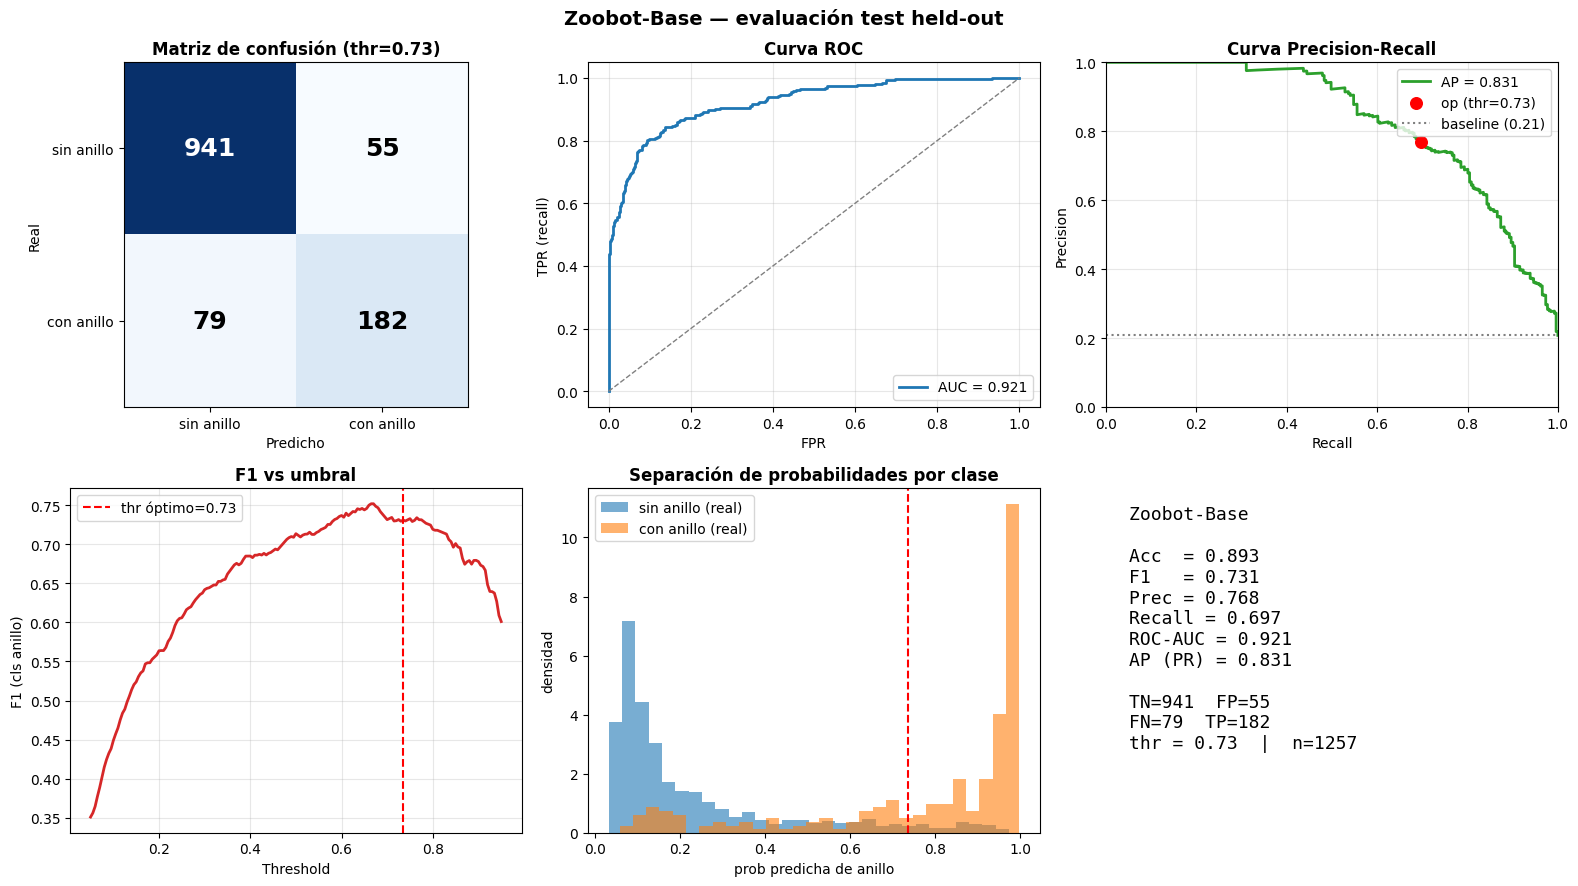

ROC-AUC=0.921  AP=0.831  F1=0.731


In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             f1_score, precision_score, recall_score)

_df = pd.read_csv(OUT_DIR / "zoobot_base_natural_predictions.csv")
_y, _p = _df.label.values, _df.prob_cls1.values
_res = json.load(open(OUT_DIR / "zoobot_base_natural_result.json"))
_THR = _res["thr"]; _pred = (_p >= _THR).astype(int)

fig, ax = plt.subplots(2, 3, figsize=(16, 9)); ax = ax.flatten()
# 1) Matriz de confusión
cm = confusion_matrix(_y, _pred, labels=[0, 1]); ax[0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=18,
                   color="white" if cm[i, j] > cm.max()/2 else "black", fontweight="bold")
ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(["sin anillo", "con anillo"]); ax[0].set_yticklabels(["sin anillo", "con anillo"])
ax[0].set_xlabel("Predicho"); ax[0].set_ylabel("Real")
ax[0].set_title(f"Matriz de confusión (thr={_THR:.2f})", fontweight="bold")
# 2) ROC
fpr, tpr, _ = roc_curve(_y, _p); _auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, lw=2, label=f"AUC = {_auc:.3f}"); ax[1].plot([0, 1], [0, 1], "--", color="gray", lw=1)
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR (recall)"); ax[1].set_title("Curva ROC", fontweight="bold")
ax[1].legend(loc="lower right"); ax[1].grid(alpha=.3)
# 3) Precision-Recall
prec, rec, _ = precision_recall_curve(_y, _p); _ap = average_precision_score(_y, _p)
ax[2].plot(rec, prec, lw=2, color="C2", label=f"AP = {_ap:.3f}")
ax[2].scatter([recall_score(_y, _pred)], [precision_score(_y, _pred)], color="red", s=70, zorder=5, label=f"op (thr={_THR:.2f})")
ax[2].axhline(_y.mean(), ls=":", color="gray", label=f"baseline ({_y.mean():.2f})")
ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision"); ax[2].set_title("Curva Precision-Recall", fontweight="bold")
ax[2].legend(loc="upper right"); ax[2].grid(alpha=.3); ax[2].set_xlim(0, 1); ax[2].set_ylim(0, 1)
# 4) F1 vs umbral
_ths = np.linspace(.05, .95, 181); _f1 = [f1_score(_y, (_p >= t).astype(int), zero_division=0) for t in _ths]
ax[3].plot(_ths, _f1, lw=2, color="C3"); ax[3].axvline(_THR, ls="--", color="red", label=f"thr óptimo={_THR:.2f}")
ax[3].set_xlabel("Threshold"); ax[3].set_ylabel("F1 (cls anillo)"); ax[3].set_title("F1 vs umbral", fontweight="bold")
ax[3].legend(); ax[3].grid(alpha=.3)
# 5) Separación de probabilidades por clase
ax[4].hist(_p[_y == 0], bins=30, alpha=.6, color="C0", label="sin anillo (real)", density=True)
ax[4].hist(_p[_y == 1], bins=30, alpha=.6, color="C1", label="con anillo (real)", density=True)
ax[4].axvline(_THR, ls="--", color="red"); ax[4].set_xlabel("prob predicha de anillo"); ax[4].set_ylabel("densidad")
ax[4].set_title("Separación de probabilidades por clase", fontweight="bold"); ax[4].legend()
# 6) resumen
tn, fp, fn, tp = cm.ravel()
_txt = (f"Zoobot-Base \n\nAcc  = {_res['acc']:.3f}\nF1   = {_res['F1']:.3f}\n"
        f"Prec = {_res['P']:.3f}\nRecall = {_res['R']:.3f}\nROC-AUC = {_auc:.3f}\nAP (PR) = {_ap:.3f}\n\n"
        f"TN={tn}  FP={fp}\nFN={fn}  TP={tp}\nthr = {_THR:.2f}  |  n={len(_y)}")
ax[5].axis("off"); ax[5].text(0.05, 0.95, _txt, va="top", ha="left", fontsize=13, family="monospace")
fig.suptitle("Zoobot-Base — evaluación test held-out", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "zoobot_base_eval_plots.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"ROC-AUC={_auc:.3f}  AP={_ap:.3f}  F1={_res['F1']:.3f}")